In [6]:
# import os
# from pathlib import Path

# print("Folders inside /kaggle/input:")
# for item in Path("/kaggle/input").iterdir():
#     print(item)

Folders inside /kaggle/input:
/kaggle/input/competitions


In [13]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/competitions/home-credit-default-risk")

print("Dataset files:")
for file in sorted(DATA_DIR.glob("*.csv")):
    print(file.name)

Dataset files:
HomeCredit_columns_description.csv
POS_CASH_balance.csv
application_test.csv
application_train.csv
bureau.csv
bureau_balance.csv
credit_card_balance.csv
installments_payments.csv
previous_application.csv
sample_submission.csv


In [15]:
import pandas as pd

files = sorted(DATA_DIR.glob("*.csv"))

for file in files:
    try:
        sample = pd.read_csv(file, nrows=5, encoding="utf-8")
        encoding_used = "utf-8"
    except UnicodeDecodeError:
        sample = pd.read_csv(file, nrows=5, encoding="latin1")
        encoding_used = "latin1"

    size_mb = file.stat().st_size / (1024 ** 2)

    print("\n" + "=" * 100)
    print(file.name)
    print("=" * 100)
    print("Size:", round(size_mb, 2), "MB")
    print("Encoding:", encoding_used)
    print("Columns:", len(sample.columns))
    print("Columns:")
    print(sample.columns.tolist())


HomeCredit_columns_description.csv
Size: 0.04 MB
Encoding: utf-8
Columns: 5
Columns:
['Unnamed: 0', 'Table', 'Row', 'Description', 'Special']

POS_CASH_balance.csv
Size: 374.51 MB
Encoding: utf-8
Columns: 8
Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']

application_test.csv
Size: 25.34 MB
Encoding: utf-8
Columns: 121
Columns:
['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CL

In [16]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/kaggle/input/competitions/home-credit-default-risk")

files_to_use = {
    "application_train": "application_train.csv",
    "bureau": "bureau.csv",
    "previous_application": "previous_application.csv",
    "installments": "installments_payments.csv",
    "description": "HomeCredit_columns_description.csv"
}

for name, filename in files_to_use.items():
    path = DATA_DIR / filename

    sample = pd.read_csv(path, nrows=5, encoding="utf-8")

    print(f"\n{name.upper()}")
    print("Rows/Columns (columns known, rows inspected later):", sample.shape)
    print("Columns:", sample.columns.tolist())


APPLICATION_TRAIN
Rows/Columns (columns known, rows inspected later): (5, 122)
Columns: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BA

In [17]:
import pandas as pd
import numpy as np

train_path = DATA_DIR / "application_train.csv"

train = pd.read_csv(train_path)

print("Shape:", train.shape)
print("\nTarget distribution:")
print(train["TARGET"].value_counts())

print("\nTarget percentage:")
print((train["TARGET"].value_counts(normalize=True) * 100).round(2))

print("\nMissing values - top 20:")
missing = (
    train.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)
display(missing.head(20))

Shape: (307511, 122)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentage:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Missing values - top 20:


COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

We need the actual:

- number of applicants: 307,511 applications
- default/non-default distribution: 8.07% defaults vs 91.93% non-defaults
- extent of missing data

imbalanced classification problem

In [18]:
# Categorize application_train columns

target = "TARGET"
id_col = "SK_ID_CURR"

numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

numeric_cols = [c for c in numeric_cols if c not in [target, id_col]]

print("Total columns:", train.shape[1])
print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)

Total columns: 122
Numeric features: 104
Categorical features: 16

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [19]:
# Missing-value summary with a simple decision view

missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_pct": train.isna().mean() * 100,
    "dtype": train.dtypes
})

missing_summary = missing_summary.sort_values(
    "missing_pct",
    ascending=False
)

display(missing_summary.head(30))

,missing_count,missing_pct,dtype
COMMONAREA_AVG,214865,69.872297,float64
COMMONAREA_MODE,214865,69.872297,float64
COMMONAREA_MEDI,214865,69.872297,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,float64
NONLIVINGAPARTMENTS_MODE,213514,69.432963,float64
NONLIVINGAPARTMENTS_AVG,213514,69.432963,float64
FONDKAPREMONT_MODE,210295,68.386172,object
LIVINGAPARTMENTS_AVG,210199,68.354953,float64
LIVINGAPARTMENTS_MEDI,210199,68.354953,float64
LIVINGAPARTMENTS_MODE,210199,68.354953,float64


In [20]:
# Initial feature selection
# Keep applicant, financial, employment and credit-related information.
# Drop highly sparse property-detail variables and IDs.

drop_cols = [
    "SK_ID_CURR",

    # Highly sparse property-detail features
    "COMMONAREA_AVG", "COMMONAREA_MODE", "COMMONAREA_MEDI",
    "NONLIVINGAPARTMENTS_AVG", "NONLIVINGAPARTMENTS_MODE", "NONLIVINGAPARTMENTS_MEDI",
    "LIVINGAPARTMENTS_AVG", "LIVINGAPARTMENTS_MODE", "LIVINGAPARTMENTS_MEDI",
    "FLOORSMIN_AVG", "FLOORSMIN_MODE", "FLOORSMIN_MEDI",
    "YEARS_BUILD_AVG", "YEARS_BUILD_MODE", "YEARS_BUILD_MEDI",
    "OWN_CAR_AGE",
    "LANDAREA_AVG", "LANDAREA_MODE", "LANDAREA_MEDI",
    "BASEMENTAREA_AVG", "BASEMENTAREA_MODE", "BASEMENTAREA_MEDI",
    "NONLIVINGAREA_AVG", "NONLIVINGAREA_MODE", "NONLIVINGAREA_MEDI",
    "ELEVATORS_AVG", "ELEVATORS_MODE", "ELEVATORS_MEDI",

    # Very sparse building-management variables
    "FONDKAPREMONT_MODE",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE",
    "EMERGENCYSTATE_MODE"
]

selected_features = [
    col for col in train.columns
    if col not in drop_cols
]

model_df = train[selected_features].copy()

print("Original shape:", train.shape)
print("New shape:", model_df.shape)
print("Features removed:", len(drop_cols) - 1)  # excluding ID
print("TARGET included:", "TARGET" in model_df.columns)

display(model_df.head())

Original shape: (307511, 122)
New shape: (307511, 89)
Features removed: 32
TARGET included: True


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


We removed these 32 columns because many had a very high percentage of missing values, some around 55–70%. They were also mostly related to detailed property information, and many of them had three similar versions: AVG, MODE, and MEDI. Keeping all these versions would make the dataset larger and more complicated without adding enough value to our main credit-risk model. So, we kept the more useful financial, demographic, employment, and credit-related features and removed these sparse property-detail features.

Removed columns — classified

1. Property condition/details

COMMONAREA_AVG, COMMONAREA_MODE, COMMONAREA_MEDI
NONLIVINGAPARTMENTS_AVG, NONLIVINGAPARTMENTS_MODE, NONLIVINGAPARTMENTS_MEDI
LIVINGAPARTMENTS_AVG, LIVINGAPARTMENTS_MODE, LIVINGAPARTMENTS_MEDI
FLOORSMIN_AVG, FLOORSMIN_MODE, FLOORSMIN_MEDI
YEARS_BUILD_AVG, YEARS_BUILD_MODE, YEARS_BUILD_MEDI
LANDAREA_AVG, LANDAREA_MODE, LANDAREA_MEDI
BASEMENTAREA_AVG, BASEMENTAREA_MODE, BASEMENTAREA_MEDI
NONLIVINGAREA_AVG, NONLIVINGAREA_MODE, NONLIVINGAREA_MEDI
ELEVATORS_AVG, ELEVATORS_MODE, ELEVATORS_MEDI

2. Other sparse property-related information

OWN_CAR_AGE
FONDKAPREMONT_MODE
HOUSETYPE_MODE
WALLSMATERIAL_MODE
EMERGENCYSTATE_MODE

In [21]:
remaining_missing = pd.DataFrame({
    "missing_count": model_df.isna().sum(),
    "missing_pct": model_df.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

display(remaining_missing.head(25))

,missing_count,missing_pct
EXT_SOURCE_1,173378,56.381073
APARTMENTS_AVG,156061,50.749729
APARTMENTS_MODE,156061,50.749729
APARTMENTS_MEDI,156061,50.749729
ENTRANCES_AVG,154828,50.348768
ENTRANCES_MODE,154828,50.348768
ENTRANCES_MEDI,154828,50.348768
LIVINGAREA_MODE,154350,50.193326
LIVINGAREA_AVG,154350,50.193326
LIVINGAREA_MEDI,154350,50.193326


In [22]:
# Feature engineering

df = model_df.copy()

# Age in years
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

# Employment duration in years
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365.25

# Credit-to-income ratio
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

# Annuity-to-income ratio
df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

# Credit-to-goods-price ratio
df["CREDIT_GOODS_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"].replace(0, np.nan)
)

print("New shape:", df.shape)
display(df[[
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO"
]].describe())

New shape: (307511, 94)


,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO
count,307511.000000,307511.000000,307511.000000,307499.000000,307233.000000
mean,43.906900,-174.716074,3.957570,0.180930,1.122995
std,11.947950,386.791969,2.689728,0.094574,0.124045
min,20.503765,-999.980835,0.004808,0.000224,0.150000
25%,33.984942,0.791239,2.018667,0.114782,1.000000
50%,43.121150,3.321013,3.265067,0.162833,1.118800
75%,53.886379,7.556468,5.159880,0.229067,1.198000
max,69.073238,49.040383,84.736842,1.875965,6.000000


In [23]:
# Fix abnormal DAYS_EMPLOYED value
#EMPLOYMENT_YEARS has negative values because DAYS_EMPLOYED contains a special value 365243, which represents an abnormal/missing employment value in this dataset.
df["EMPLOYMENT_YEARS"] = np.where(
    df["DAYS_EMPLOYED"] == 365243,
    np.nan,
    -df["DAYS_EMPLOYED"] / 365.25
)

# Recheck
print(df["EMPLOYMENT_YEARS"].describe())

count    252137.000000
mean          6.527500
std           6.402081
min           0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64


In [24]:
display(
    df[
        [
            "AGE_YEARS",
            "EMPLOYMENT_YEARS",
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "CREDIT_GOODS_RATIO"
        ]
    ].describe()
)

,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO
count,307511.000000,252137.000000,307511.000000,307499.000000,307233.000000
mean,43.906900,6.527500,3.957570,0.180930,1.122995
std,11.947950,6.402081,2.689728,0.094574,0.124045
min,20.503765,0.000000,0.004808,0.000224,0.150000
25%,33.984942,2.099932,2.018667,0.114782,1.000000
50%,43.121150,4.511978,3.265067,0.162833,1.118800
75%,53.886379,8.692676,5.159880,0.229067,1.198000
max,69.073238,49.040383,84.736842,1.875965,6.000000


In [25]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True).round(4))

Training: (246008, 93) (246008,)
Validation: (61503, 93) (61503,)

Training target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

import lightgbm as lgb

# Identify columns by type
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Numeric preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

# Combined preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Calculate class imbalance
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative class:", negative)
print("Positive class:", positive)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Numeric features: 81
Categorical features: 12
Negative class: 226148
Positive class: 19860
scale_pos_weight: 11.39


scale_pos_weight = 11.39 → correct for the class imbalance.

In [27]:
# Fit preprocessing on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_valid_processed.shape)

Processed training shape: (246008, 205)
Processed validation shape: (61503, 205)


In [28]:
model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed,y_train)

print("Model training completed.")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7495
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 194
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Model training completed.


In [29]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Validation probabilities
y_valid_proba = model.predict_proba(X_valid_processed)[:, 1]

# Default threshold for now
y_valid_pred = (y_valid_proba >= 0.50).astype(int)

# Metrics
roc_auc = roc_auc_score(y_valid, y_valid_proba)
pr_auc = average_precision_score(y_valid, y_valid_proba)
precision = precision_score(y_valid, y_valid_pred)
recall = recall_score(y_valid, y_valid_pred)
f1 = f1_score(y_valid, y_valid_pred)

print("ROC-AUC :", round(roc_auc, 4))
print("PR-AUC  :", round(pr_auc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC : 0.7619
PR-AUC  : 0.2538
Precision: 0.1763
Recall   : 0.6624
F1-score : 0.2785

Confusion Matrix:
[[41176 15362]
 [ 1676  3289]]


The confusion matrix also shows the trade-off caused by scale_pos_weight=11.39: we're catching many defaults, but we're also generating a lot of false positives.

#baseline

In [30]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_valid,y_valid_proba)
f1_scores = (2 * precision[:-1] * recall[:-1]/ (precision[:-1] + recall[:-1] + 1e-10))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", round(best_threshold, 4))
print("Best F1:", round(best_f1, 4))
print("Precision:", round(precision[best_idx], 4))
print("Recall:", round(recall[best_idx], 4))

Best threshold: 0.6333
Best F1: 0.3109
Precision: 0.2357
Recall: 0.4566


Baseline LightGBM: ROC-AUC 0.7619, PR-AUC 0.2538.
An optimized classification threshold of 0.6333 improved F1 from 0.2785 to 0.3109.

In [33]:
# Get the real feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(20))

,feature,importance
28,num__EXT_SOURCE_3,863
26,num__EXT_SOURCE_1,725
27,num__EXT_SOURCE_2,718
9,num__DAYS_ID_PUBLISH,659
49,num__DAYS_LAST_PHONE_CHANGE,609
3,num__AMT_ANNUITY,588
8,num__DAYS_REGISTRATION,548
6,num__DAYS_BIRTH,505
78,num__CREDIT_INCOME_RATIO,487
2,num__AMT_CREDIT,473


The model is relying heavily on:

EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 → strongest predictors
DAYS_ID_PUBLISH, DAYS_LAST_PHONE_CHANGE, DAYS_REGISTRATION, DAYS_BIRTH
AMT_ANNUITY, AMT_CREDIT, AMT_INCOME_TOTAL
our engineered ratios such as CREDIT_INCOME_RATIO and ANNUITY_INCOME_RATIO

That is a sensible pattern for a credit-risk model.

3 useful aggregates from bureau.csv and previous_application.csv, rather than processing all the historical tables.

In [34]:
#Bureau aggregates

In [35]:
import pandas as pd
import numpy as np

bureau_path = DATA_DIR / "bureau.csv"

bureau_agg_list = []

for chunk in pd.read_csv(bureau_path, chunksize=100000):
    
    # Keep only useful columns
    chunk = chunk[
        [
            "SK_ID_CURR",
            "CREDIT_ACTIVE",
            "CREDIT_DAY_OVERDUE",
            "AMT_CREDIT_SUM",
            "AMT_CREDIT_SUM_DEBT",
            "AMT_CREDIT_SUM_OVERDUE"
        ]
    ]

    # Applicant-level aggregation
    agg = chunk.groupby("SK_ID_CURR").agg(
        BUREAU_CREDIT_COUNT=("SK_ID_CURR", "count"),
        BUREAU_ACTIVE_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
        BUREAU_OVERDUE_COUNT=("CREDIT_DAY_OVERDUE", lambda x: (x > 0).sum()),
        BUREAU_CREDIT_SUM=("AMT_CREDIT_SUM", "sum"),
        BUREAU_DEBT_SUM=("AMT_CREDIT_SUM_DEBT", "sum"),
        BUREAU_OVERDUE_SUM=("AMT_CREDIT_SUM_OVERDUE", "sum")
    ).reset_index()

    bureau_agg_list.append(agg)

bureau_agg = pd.concat(bureau_agg_list, ignore_index=True)

# Because the same applicant may occur in multiple chunks,
# aggregate once more.
bureau_agg = bureau_agg.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_COUNT=("BUREAU_CREDIT_COUNT", "sum"),
    BUREAU_ACTIVE_COUNT=("BUREAU_ACTIVE_COUNT", "sum"),
    BUREAU_OVERDUE_COUNT=("BUREAU_OVERDUE_COUNT", "sum"),
    BUREAU_CREDIT_SUM=("BUREAU_CREDIT_SUM", "sum"),
    BUREAU_DEBT_SUM=("BUREAU_DEBT_SUM", "sum"),
    BUREAU_OVERDUE_SUM=("BUREAU_OVERDUE_SUM", "sum")
).reset_index()

print("Bureau aggregated shape:", bureau_agg.shape)
display(bureau_agg.head())

Bureau aggregated shape: (305811, 7)


,SK_ID_CURR,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_OVERDUE_COUNT,BUREAU_CREDIT_SUM,BUREAU_DEBT_SUM,BUREAU_OVERDUE_SUM
0,100001,7,3,0,1453365.000,596686.5,0.0
1,100002,8,2,0,865055.565,245781.0,0.0
2,100003,4,1,0,1017400.500,0.0,0.0
3,100004,2,0,0,189037.800,0.0,0.0
4,100005,3,2,0,657126.000,568408.5,0.0


In [36]:
previous_path = DATA_DIR / "previous_application.csv"

previous_agg_list = []

for chunk in pd.read_csv(previous_path, chunksize=100000):

    chunk = chunk[
        [
            "SK_ID_CURR",
            "AMT_APPLICATION",
            "AMT_CREDIT",
            "NAME_CONTRACT_STATUS"
        ]
    ]

    agg = chunk.groupby("SK_ID_CURR").agg(
        PREV_APPLICATION_COUNT=("SK_ID_CURR", "count"),
        PREV_AVG_APPLICATION=("AMT_APPLICATION", "mean"),
        PREV_AVG_CREDIT=("AMT_CREDIT", "mean"),
        PREV_APPROVED_COUNT=(
            "NAME_CONTRACT_STATUS",
            lambda x: (x == "Approved").sum()
        ),
        PREV_REFUSED_COUNT=(
            "NAME_CONTRACT_STATUS",
            lambda x: (x == "Refused").sum()
        )
    ).reset_index()

    previous_agg_list.append(agg)

previous_agg = pd.concat(
    previous_agg_list,
    ignore_index=True
)

previous_agg = previous_agg.groupby("SK_ID_CURR").agg(
    PREV_APPLICATION_COUNT=("PREV_APPLICATION_COUNT", "sum"),
    PREV_AVG_APPLICATION=("PREV_AVG_APPLICATION", "mean"),
    PREV_AVG_CREDIT=("PREV_AVG_CREDIT", "mean"),
    PREV_APPROVED_COUNT=("PREV_APPROVED_COUNT", "sum"),
    PREV_REFUSED_COUNT=("PREV_REFUSED_COUNT", "sum")
).reset_index()

print("Previous application aggregated shape:", previous_agg.shape)
display(previous_agg.head())

Previous application aggregated shape: (338857, 6)


,SK_ID_CURR,PREV_APPLICATION_COUNT,PREV_AVG_APPLICATION,PREV_AVG_CREDIT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT
0,100001,1,24835.50,23787.00,1,0
1,100002,1,179055.00,179055.00,1,0
2,100003,3,435436.50,484191.00,3,0
3,100004,1,24282.00,20106.00,1,0
4,100005,2,22308.75,20076.75,1,0


In [38]:
# Add applicant ID back only for merging
df["SK_ID_CURR"] = train["SK_ID_CURR"].values

print(df.shape)
print(df["SK_ID_CURR"].nunique())

(307511, 95)
307511


In [39]:
df_final = df.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

df_final = df_final.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

print("Final shape:", df_final.shape)
display(df_final.head())

Final shape: (307511, 106)


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,BUREAU_ACTIVE_COUNT,BUREAU_OVERDUE_COUNT,BUREAU_CREDIT_SUM,BUREAU_DEBT_SUM,BUREAU_OVERDUE_SUM,PREV_APPLICATION_COUNT,PREV_AVG_APPLICATION,PREV_AVG_CREDIT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,2.0,0.0,865055.565,245781.0,0.0,1.0,179055.00,179055.0,1.0,0.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,1.0,0.0,1017400.500,0.0,0.0,3.0,435436.50,484191.0,3.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,189037.800,0.0,0.0,1.0,24282.00,20106.0,1.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,NaN,NaN,NaN,NaN,NaN,9.0,272203.26,291695.5,5.0,1.0
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,146250.000,0.0,0.0,6.0,140136.30,153526.5,6.0,0.0


Original application_train     307,511 rows × 122 columns
After initial feature selection 307,511 × 89
After feature engineering       307,511 × 94
After historical aggregates     307,511 × 106

In [40]:
print("Shape:", df_final.shape)

print("\nColumns added from historical data:")
historical_cols = [
    c for c in df_final.columns
    if c.startswith("BUREAU_") or c.startswith("PREV_")
]

print(historical_cols)
print("Number of historical features:", len(historical_cols))

Shape: (307511, 106)

Columns added from historical data:
['BUREAU_CREDIT_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_OVERDUE_COUNT', 'BUREAU_CREDIT_SUM', 'BUREAU_DEBT_SUM', 'BUREAU_OVERDUE_SUM', 'PREV_APPLICATION_COUNT', 'PREV_AVG_APPLICATION', 'PREV_AVG_CREDIT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT']
Number of historical features: 11


In [41]:
print("Duplicate applicant IDs:", df_final["SK_ID_CURR"].duplicated().sum())
print("Rows:", len(df_final))
print("Unique applicants:", df_final["SK_ID_CURR"].nunique())

Duplicate applicant IDs: 0
Rows: 307511
Unique applicants: 307511


What the 12 new columns are

Bureau:

BUREAU_CREDIT_COUNT
BUREAU_ACTIVE_COUNT
BUREAU_OVERDUE_COUNT
BUREAU_CREDIT_SUM
BUREAU_DEBT_SUM
BUREAU_OVERDUE_SUM

Previous applications:

PREV_APPLICATION_COUNT
PREV_AVG_APPLICATION
PREV_AVG_CREDIT
PREV_APPROVED_COUNT
PREV_REFUSED_COUNT

Plus the two ratios we added afterward should make it 108

In [42]:
# Add historical ratio features

df_final["BUREAU_DEBT_TO_CREDIT"] = (
    df_final["BUREAU_DEBT_SUM"] /
    df_final["BUREAU_CREDIT_SUM"].replace(0, np.nan)
)

df_final["PREV_REFUSAL_RATE"] = (
    df_final["PREV_REFUSED_COUNT"] /
    df_final["PREV_APPLICATION_COUNT"].replace(0, np.nan)
)

print("Final shape:", df_final.shape)

Final shape: (307511, 108)


In [43]:
from sklearn.model_selection import train_test_split

X_final = df_final.drop(columns=["TARGET", "SK_ID_CURR"])
y_final = df_final["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(X_final,y_final,test_size=0.20,stratify=y_final,random_state=42)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)

Training: (246008, 106)
Validation: (61503, 106)


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor_final = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor_final.fit_transform(X_train)
X_valid_processed = preprocessor_final.transform(X_valid)

print("Processed training:", X_train_processed.shape)
print("Processed validation:", X_valid_processed.shape)

Processed training: (246008, 218)
Processed validation: (61503, 218)


In [45]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight_final = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("scale_pos_weight:", round(scale_pos_weight_final, 2))

Negative: 226148
Positive: 19860
scale_pos_weight: 11.39


In [46]:
import lightgbm as lgb

model_final = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_final,
    random_state=42,
    n_jobs=-1
)

model_final.fit(
    X_train_processed,
    y_train
)

print("Final model trained.")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.152659 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9383
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 207
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Final model trained.


In [47]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_valid_proba = model_final.predict_proba(
    X_valid_processed
)[:, 1]

y_valid_pred = (y_valid_proba >= 0.5).astype(int)

print("ROC-AUC :", round(
    roc_auc_score(y_valid, y_valid_proba), 4
))

print("PR-AUC  :", round(
    average_precision_score(y_valid, y_valid_proba), 4
))

print("Precision:", round(
    precision_score(y_valid, y_valid_pred), 4
))

print("Recall   :", round(
    recall_score(y_valid, y_valid_pred), 4
))

print("F1-score :", round(
    f1_score(y_valid, y_valid_pred), 4
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC : 0.769
PR-AUC  : 0.2609
Precision: 0.1818
Recall   : 0.6663
F1-score : 0.2857

Confusion Matrix:
[[41653 14885]
 [ 1657  3308]]


In [48]:
from sklearn.metrics import roc_auc_score, average_precision_score

model_tuned = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight_final,
    random_state=42,
    n_jobs=-1
)

model_tuned.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_valid_processed, y_valid)],
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

y_valid_proba_tuned = model_tuned.predict_proba(
    X_valid_processed
)[:, 1]

print("Best iteration:", model_tuned.best_iteration_)
print("ROC-AUC:", round(roc_auc_score(y_valid, y_valid_proba_tuned), 4))
print("PR-AUC :", round(average_precision_score(y_valid, y_valid_proba_tuned), 4))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.155221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9381
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 206
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.551082
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 0.276951
Best iteration: 2
ROC-AUC: 0.7262
PR-AUC : 0.1973


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [49]:
from sklearn.metrics import precision_recall_curve

y_proba = model_final.predict_proba(X_valid_processed)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_valid,
    y_proba
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Final threshold:", round(best_threshold, 4))
print("Final F1:", round(f1_scores[best_idx], 4))
print("Final Precision:", round(precision[best_idx], 4))
print("Final Recall:", round(recall[best_idx], 4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final threshold: 0.6525
Final F1: 0.3209
Final Precision: 0.2551
Final Recall: 0.4324


In [51]:
installments_path = DATA_DIR / "installments_payments.csv"

installment_parts = []

for chunk in pd.read_csv(installments_path, chunksize=100000):

    chunk = chunk[
        [
            "SK_ID_CURR",
            "DAYS_INSTALMENT",
            "DAYS_ENTRY_PAYMENT",
            "AMT_INSTALMENT",
            "AMT_PAYMENT"
        ]
    ]

    # Payment delay: positive means payment was made late
    chunk["PAYMENT_DELAY_DAYS"] = (
        chunk["DAYS_ENTRY_PAYMENT"] - chunk["DAYS_INSTALMENT"]
    )

    # Payment shortfall
    chunk["PAYMENT_SHORTFALL"] = (
        chunk["AMT_INSTALMENT"] - chunk["AMT_PAYMENT"]
    )

    agg = chunk.groupby("SK_ID_CURR").agg(
        INSTALLMENT_COUNT=("SK_ID_CURR", "count"),
        AVG_PAYMENT_DELAY=("PAYMENT_DELAY_DAYS", "mean"),
        LATE_PAYMENT_COUNT=("PAYMENT_DELAY_DAYS", lambda x: (x > 0).sum()),
        TOTAL_PAYMENT_SHORTFALL=("PAYMENT_SHORTFALL", "sum"),
        AVG_PAYMENT_SHORTFALL=("PAYMENT_SHORTFALL", "mean"),
        TOTAL_INSTALLMENT_AMOUNT=("AMT_INSTALMENT", "sum"),
        TOTAL_PAYMENT_AMOUNT=("AMT_PAYMENT", "sum")
    ).reset_index()

    installment_parts.append(agg)

installment_agg = pd.concat(
    installment_parts,
    ignore_index=True
)

# Combine chunks by applicant
installment_agg = installment_agg.groupby("SK_ID_CURR").agg(
    INSTALLMENT_COUNT=("INSTALLMENT_COUNT", "sum"),
    AVG_PAYMENT_DELAY=("AVG_PAYMENT_DELAY", "mean"),
    LATE_PAYMENT_COUNT=("LATE_PAYMENT_COUNT", "sum"),
    TOTAL_PAYMENT_SHORTFALL=("TOTAL_PAYMENT_SHORTFALL", "sum"),
    AVG_PAYMENT_SHORTFALL=("AVG_PAYMENT_SHORTFALL", "mean"),
    TOTAL_INSTALLMENT_AMOUNT=("TOTAL_INSTALLMENT_AMOUNT", "sum"),
    TOTAL_PAYMENT_AMOUNT=("TOTAL_PAYMENT_AMOUNT", "sum")
).reset_index()

print("Installment aggregated shape:", installment_agg.shape)
display(installment_agg.head())

Installment aggregated shape: (339587, 8)


,SK_ID_CURR,INSTALLMENT_COUNT,AVG_PAYMENT_DELAY,LATE_PAYMENT_COUNT,TOTAL_PAYMENT_SHORTFALL,AVG_PAYMENT_SHORTFALL,TOTAL_INSTALLMENT_AMOUNT,TOTAL_PAYMENT_AMOUNT
0,100001,7,-7.583333,1,0.0,0.0,41195.925,41195.925
1,100002,19,-20.264706,0,0.0,0.0,219625.695,219625.695
2,100003,25,-7.105263,0,0.0,0.0,1618864.650,1618864.650
3,100004,3,-7.666667,0,0.0,0.0,21288.465,21288.465
4,100005,9,-24.375000,1,0.0,0.0,56161.845,56161.845


In [52]:
df_final = df_final.merge(
    installment_agg,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one"
)

# Additional repayment ratio
df_final["PAYMENT_TO_INSTALLMENT_RATIO"] = (
    df_final["TOTAL_PAYMENT_AMOUNT"] /
    df_final["TOTAL_INSTALLMENT_AMOUNT"].replace(0, np.nan)
)

print("Final dataset shape:", df_final.shape)

Final dataset shape: (307511, 116)


In [53]:
# Final ML dataset

X_final = df_final.drop(columns=["TARGET", "SK_ID_CURR"])
y_final = df_final["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    stratify=y_final,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)

Training: (246008, 114)
Validation: (61503, 114)


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor_final = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor_final.fit_transform(X_train)
X_valid_processed = preprocessor_final.transform(X_valid)

print("Processed training:", X_train_processed.shape)
print("Processed validation:", X_valid_processed.shape)

Numeric features: 102
Categorical features: 12
Processed training: (246008, 226)
Processed validation: (61503, 226)


In [55]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight_final = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("scale_pos_weight:", round(scale_pos_weight_final, 2))

Negative: 226148
Positive: 19860
scale_pos_weight: 11.39


In [56]:
import lightgbm as lgb

model_final_all = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_final,
    random_state=42,
    n_jobs=-1
)

model_final_all.fit(
    X_train_processed,
    y_train
)

print("Final model trained.")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11254
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 215
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Final model trained.


In [57]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_valid_proba = model_final_all.predict_proba(
    X_valid_processed
)[:, 1]

y_valid_pred = (y_valid_proba >= 0.5).astype(int)

print("ROC-AUC :", round(roc_auc_score(y_valid, y_valid_proba), 4))
print("PR-AUC  :", round(average_precision_score(y_valid, y_valid_proba), 4))
print("Precision:", round(precision_score(y_valid, y_valid_pred), 4))
print("Recall   :", round(recall_score(y_valid, y_valid_pred), 4))
print("F1-score :", round(f1_score(y_valid, y_valid_pred), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC : 0.7738
PR-AUC  : 0.2688
Precision: 0.1847
Recall   : 0.6661
F1-score : 0.2892

Confusion Matrix:
[[41943 14595]
 [ 1658  3307]]


So adding the installment/repayment features did improve the model.

| Model                                |    ROC-AUC |     PR-AUC |  F1 @ 0.50 |
| ------------------------------------ | ---------: | ---------: | ---------: |
| Application + historical features    |     0.7690 |     0.2609 |     0.2857 |
| **Complete pipeline + installments** | **0.7738** | **0.2688** | **0.2892** |

application data + bureau + previous applications + repayment behaviour → ML

In [58]:
from sklearn.metrics import precision_recall_curve

y_proba_final = model_final_all.predict_proba(
    X_valid_processed
)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_valid,
    y_proba_final
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

final_threshold = thresholds[best_idx]

print("Final threshold:", round(final_threshold, 4))
print("Final F1:", round(f1_scores[best_idx], 4))
print("Final Precision:", round(precision[best_idx], 4))
print("Final Recall:", round(recall[best_idx], 4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final threshold: 0.6622
Final F1: 0.3248
Final Precision: 0.2652
Final Recall: 0.4187


In [60]:
import joblib
from pathlib import Path

Path("/kaggle/working/models").mkdir(parents=True, exist_ok=True)

joblib.dump(
    model_final_all,
    "/kaggle/working/models/model.pkl"
)

joblib.dump(
    preprocessor_final,
    "/kaggle/working/models/preprocessor.pkl"
)

joblib.dump(
    preprocessor_final.get_feature_names_out(),
    "/kaggle/working/models/feature_names.pkl"
)

joblib.dump(
    final_threshold,
    "/kaggle/working/models/threshold.pkl"
)

print("Best model artifacts saved.")

Best model artifacts saved.


#SHAP — first global explanation

In [61]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names
feature_names = preprocessor_final.get_feature_names_out()

# Use a manageable sample for SHAP
sample_size = 2000

X_shap = X_valid_processed[:sample_size]

# SHAP explainer for LightGBM
explainer = shap.TreeExplainer(model_final_all)

shap_values = explainer.shap_values(X_shap)

# For binary classification, use class 1
shap_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

print("SHAP shape:", shap_class1.shape)

SHAP shape: (2000, 226)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


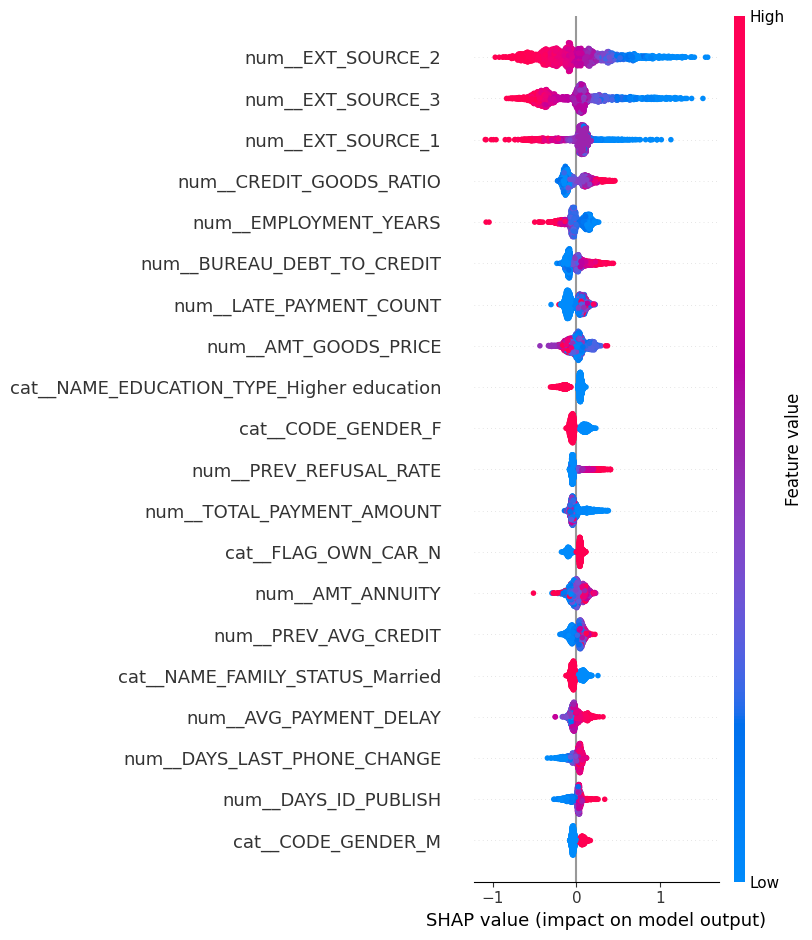

In [62]:
shap.summary_plot(
    shap_class1,
    X_shap,
    feature_names=feature_names,
    max_display=20
)

The strongest overall drivers in your model are:

EXT_SOURCE_2
EXT_SOURCE_3
EXT_SOURCE_1
CREDIT_GOODS_RATIO
EMPLOYMENT_YEARS
BUREAU_DEBT_TO_CREDIT
LATE_PAYMENT_COUNT

That is actually useful because it shows the model is using external credit indicators + financial burden + employment + historical credit/repayment behaviour

In [64]:
# Individual SHAP explanation

applicant_index = 0

# Select one applicant
applicant_data = X_valid.iloc[[applicant_index]]

# Transform using the same fitted preprocessing pipeline
applicant_processed = preprocessor_final.transform(applicant_data)

# Prediction probability
risk_probability = model_final_all.predict_proba(
    applicant_processed
)[0, 1]

# Risk band
if risk_probability < 0.30:
    risk_band = "Low"
elif risk_probability < final_threshold:
    risk_band = "Medium"
else:
    risk_band = "High"

print("Risk probability:", round(risk_probability, 4))
print("Risk score:", round(risk_probability * 100, 2))
print("Risk band:", risk_band)

# SHAP
explainer = shap.TreeExplainer(model_final_all)

shap_values = explainer.shap_values(
    applicant_processed
)

# Handle different SHAP versions
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_values = shap_values[0]

# Convert sparse matrix only if necessary
if hasattr(applicant_processed, "toarray"):
    applicant_values = applicant_processed.toarray()[0]
else:
    applicant_values = applicant_processed[0]

# Explanation table
explanation = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values,
    "feature_value": applicant_values
})

# Top factors increasing risk
risk_increasing = (
    explanation[explanation["shap_value"] > 0]
    .sort_values("shap_value", ascending=False)
    .head(5)
)

# Top factors reducing risk
risk_reducing = (
    explanation[explanation["shap_value"] < 0]
    .sort_values("shap_value")
    .head(5)
)

print("\nTop factors increasing risk:")
display(risk_increasing)

print("\nTop factors reducing risk:")
display(risk_reducing)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Risk probability: 0.2874
Risk score: 28.74
Risk band: Low

Top factors increasing risk:


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,shap_value,feature_value
77,num__EMPLOYMENT_YEARS,0.187045,0.287474
28,num__EXT_SOURCE_3,0.165871,0.427657
100,num__TOTAL_PAYMENT_AMOUNT,0.115566,87012.540000
82,num__BUREAU_ACTIVE_COUNT,0.114773,4.000000
26,num__EXT_SOURCE_1,0.106002,0.505446



Top factors reducing risk:


,feature,shap_value,feature_value
4,num__AMT_GOODS_PRICE,-0.232385,688500.000000
127,cat__NAME_EDUCATION_TYPE_Higher education,-0.156491,1.000000
92,num__BUREAU_DEBT_TO_CREDIT,-0.127923,0.152082
27,num__EXT_SOURCE_2,-0.127826,0.594327
74,num__AMT_REQ_CREDIT_BUREAU_QRT,-0.099843,1.000000


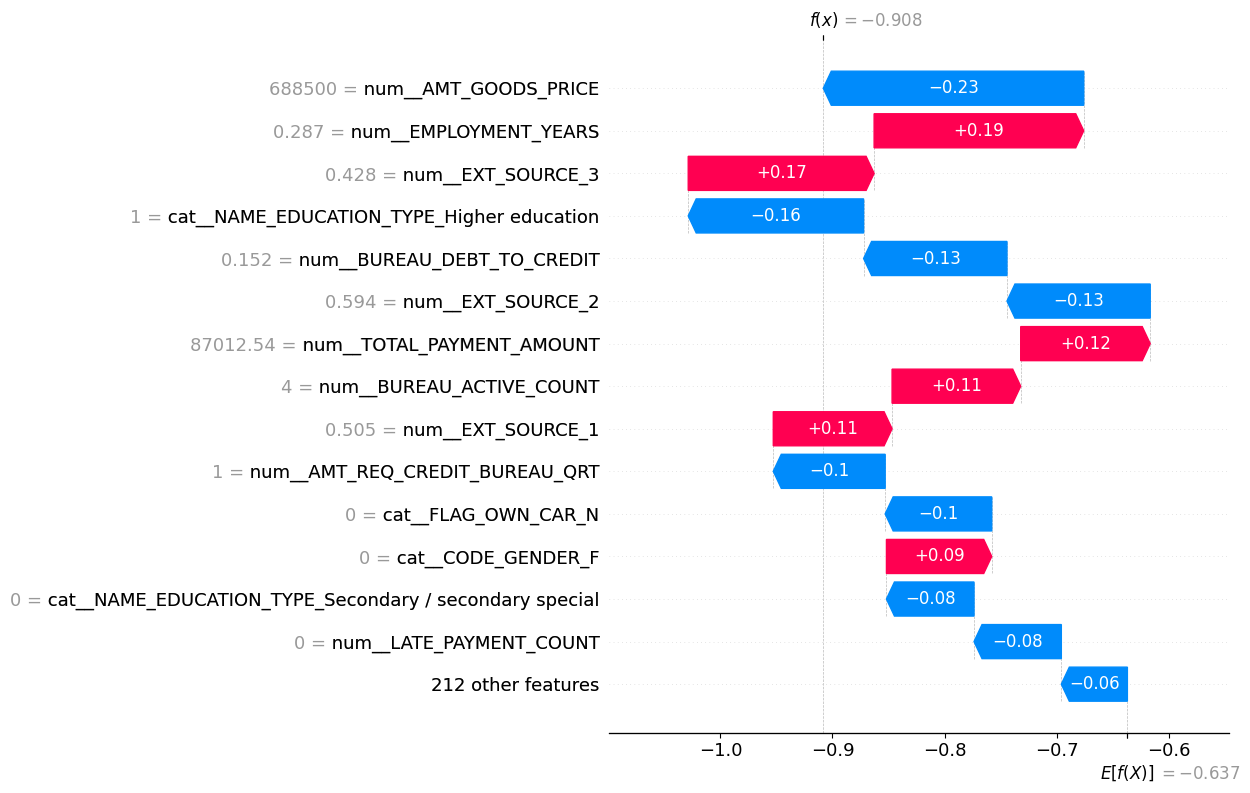

In [65]:
# Individual SHAP waterfall plot

base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=applicant_values,
    feature_names=feature_names
)

shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

What the SHAP result means

Factors increasing risk

EMPLOYMENT_YEARS
EXT_SOURCE_3
TOTAL_PAYMENT_AMOUNT
BUREAU_ACTIVE_COUNT
EXT_SOURCE_1

Factors reducing risk

AMT_GOODS_PRICE
Higher education
BUREAU_DEBT_TO_CREDIT
EXT_SOURCE_2
AMT_REQ_CREDIT_BUREAU_QRT

A positive SHAP value pushes the prediction toward higher default risk, while a negative SHAP value pushes it toward lower risk.

The waterfall chart is also valid. The f(x) value shown by SHAP is on the model's internal output scale, so don't present f(x) = -0.908 as the applicant's probability

Global SHAP → overall important features

Individual SHAP → why one applicant received their risk score

In [66]:
#Business Rule
# Business-readable rules derived from the data and model

# Key risk-related features selected from our model/SHAP results
rule_features = [
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_1",
    "CREDIT_INCOME_RATIO",
    "EMPLOYMENT_YEARS",
    "BUREAU_DEBT_TO_CREDIT",
    "PREV_REFUSAL_RATE",
    "AVG_PAYMENT_DELAY",
    "LATE_PAYMENT_COUNT"
]

rule_features = [
    col for col in rule_features
    if col in df_final.columns
]

rules = []

for col in rule_features:

    temp = df_final[[col, "TARGET"]].dropna().copy()

    # Create 4 risk groups based on the actual data distribution
    temp["group"] = pd.qcut(
        temp[col],
        q=4,
        duplicates="drop"
    )

    summary = (
        temp.groupby("group", observed=True)["TARGET"]
        .agg(
            applications="count",
            default_rate="mean"
        )
        .reset_index()
    )

    summary["default_rate"] *= 100

    # Compare lowest and highest groups
    lowest_rate = summary.iloc[0]["default_rate"]
    highest_rate = summary.iloc[-1]["default_rate"]

    if highest_rate > lowest_rate:
        direction = "Higher values are associated with higher observed default risk."
    else:
        direction = "Lower values are associated with higher observed default risk."

    rules.append({
        "feature": col,
        "lowest_group_default_rate": round(lowest_rate, 2),
        "highest_group_default_rate": round(highest_rate, 2),
        "interpretation": direction
    })

rules_df = pd.DataFrame(rules)

display(rules_df)

,feature,lowest_group_default_rate,highest_group_default_rate,interpretation
0,EXT_SOURCE_2,14.29,3.80,Lower values are associated with higher observ...
1,EXT_SOURCE_3,15.06,3.52,Lower values are associated with higher observ...
2,EXT_SOURCE_1,13.56,3.27,Lower values are associated with higher observ...
3,CREDIT_INCOME_RATIO,7.46,7.37,Lower values are associated with higher observ...
4,EMPLOYMENT_YEARS,11.21,5.42,Lower values are associated with higher observ...
5,BUREAU_DEBT_TO_CREDIT,5.64,11.47,Higher values are associated with higher obser...
6,PREV_REFUSAL_RATE,7.16,11.63,Higher values are associated with higher obser...
7,AVG_PAYMENT_DELAY,6.93,9.82,Higher values are associated with higher obser...
8,LATE_PAYMENT_COUNT,7.18,9.82,Higher values are associated with higher obser...


In [67]:
# Convert the actual findings into readable rules

business_rules = []

for _, row in rules_df.iterrows():

    feature = row["feature"]

    if feature == "EXT_SOURCE_2":
        rule_name = "External credit indicator"
        
    elif feature == "EXT_SOURCE_3":
        rule_name = "External credit indicator"
        
    elif feature == "EXT_SOURCE_1":
        rule_name = "External credit indicator"
        
    elif feature == "CREDIT_INCOME_RATIO":
        rule_name = "Credit burden relative to income"
        
    elif feature == "EMPLOYMENT_YEARS":
        rule_name = "Employment stability"
        
    elif feature == "BUREAU_DEBT_TO_CREDIT":
        rule_name = "Existing debt relative to historical credit"
        
    elif feature == "PREV_REFUSAL_RATE":
        rule_name = "Previous application refusal rate"
        
    elif feature == "AVG_PAYMENT_DELAY":
        rule_name = "Previous payment behaviour"
        
    elif feature == "LATE_PAYMENT_COUNT":
        rule_name = "Number of late payments"
        
    else:
        rule_name = feature

    business_rules.append({
        "Business factor": rule_name,
        "Model feature": feature,
        "Observed relationship": row["interpretation"],
        "Lower-group default %": row["lowest_group_default_rate"],
        "Higher-group default %": row["highest_group_default_rate"]
    })

business_rules_df = pd.DataFrame(business_rules)

display(business_rules_df)

,Business factor,Model feature,Observed relationship,Lower-group default %,Higher-group default %
0,External credit indicator,EXT_SOURCE_2,Lower values are associated with higher observ...,14.29,3.80
1,External credit indicator,EXT_SOURCE_3,Lower values are associated with higher observ...,15.06,3.52
2,External credit indicator,EXT_SOURCE_1,Lower values are associated with higher observ...,13.56,3.27
3,Credit burden relative to income,CREDIT_INCOME_RATIO,Lower values are associated with higher observ...,7.46,7.37
4,Employment stability,EMPLOYMENT_YEARS,Lower values are associated with higher observ...,11.21,5.42
5,Existing debt relative to historical credit,BUREAU_DEBT_TO_CREDIT,Higher values are associated with higher obser...,5.64,11.47
6,Previous application refusal rate,PREV_REFUSAL_RATE,Higher values are associated with higher obser...,7.16,11.63
7,Previous payment behaviour,AVG_PAYMENT_DELAY,Higher values are associated with higher obser...,6.93,9.82
8,Number of late payments,LATE_PAYMENT_COUNT,Higher values are associated with higher obser...,7.18,9.82


In [68]:
def generate_business_reasons(applicant_row, shap_values, feature_names):
    
    explanation = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values
    })

    explanation["abs_shap"] = explanation["shap_value"].abs()

    top_features = (
        explanation
        .sort_values("abs_shap", ascending=False)
        .head(5)
    )

    reasons = []

    for _, row in top_features.iterrows():

        feature = row["feature"]
        shap_value = row["shap_value"]

        # Remove preprocessing prefixes
        clean_feature = feature.replace("num__", "").replace("cat__", "")

        if shap_value > 0:
            reasons.append(
                f"{clean_feature} increased the predicted default risk."
            )
        else:
            reasons.append(
                f"{clean_feature} reduced the predicted default risk."
            )

    return reasons

This gives us ML-derived explanations
The useful findings are clear:

EXT_SOURCE_1/2/3 → lower values are associated with higher default rates.
BUREAU_DEBT_TO_CREDIT → higher values are associated with higher default rates.
PREV_REFUSAL_RATE → higher values are associated with higher default rates.
AVG_PAYMENT_DELAY → higher delay is associated with higher default rates.
LATE_PAYMENT_COUNT → more late payments are associated with higher default rates.
EMPLOYMENT_YEARS → lower employment duration is associated with higher default rates.

CREDIT_INCOME_RATIO is not showing a meaningful difference here (7.46% vs 7.37%),

## Business-Readable Credit Risk Rules

Based on the observed default-rate patterns and model explainability analysis:

1. **External Credit Score**
   Lower EXT_SOURCE scores are associated with higher observed default risk.

2. **Existing Debt Burden**
   Higher BUREAU_DEBT_TO_CREDIT is associated with higher observed default risk.

3. **Previous Application History**
   A higher PREV_REFUSAL_RATE is associated with higher observed default risk.

4. **Repayment Behaviour**
   Higher AVG_PAYMENT_DELAY is associated with higher observed default risk.

5. **Late Payment History**
   A higher LATE_PAYMENT_COUNT is associated with higher observed default risk.

In [70]:
import json
from pathlib import Path

Path("/kaggle/working/models").mkdir(parents=True, exist_ok=True)

with open("/kaggle/working/models/business_rules.json", "w") as f:
    json.dump(business_rules, f, indent=4)

print("Business rules saved successfully.")

Business rules saved successfully.


In [72]:
#Nl
import duckdb
import pandas as pd

# Keep only columns needed for business analysis
analytics_cols = [
    "TARGET",
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "BUREAU_CREDIT_COUNT",
    "BUREAU_ACTIVE_COUNT",
    "BUREAU_OVERDUE_COUNT",
    "PREV_APPLICATION_COUNT",
    "PREV_APPROVED_COUNT",
    "PREV_REFUSED_COUNT",
    "PREV_REFUSAL_RATE",
    "AVG_PAYMENT_DELAY",
    "LATE_PAYMENT_COUNT",
    "BUREAU_DEBT_TO_CREDIT",
    "PAYMENT_TO_INSTALLMENT_RATIO"
]

analytics_df = df_final[analytics_cols].copy()

# Create readable target/risk columns
analytics_df["DEFAULT_STATUS"] = analytics_df["TARGET"].map({
    0: "No Default",
    1: "Default"
})

print("Analytics dataset:", analytics_df.shape)
display(analytics_df.head())

Analytics dataset: (307511, 27)


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_OVERDUE_COUNT,PREV_APPLICATION_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_REFUSAL_RATE,AVG_PAYMENT_DELAY,LATE_PAYMENT_COUNT,BUREAU_DEBT_TO_CREDIT,PAYMENT_TO_INSTALLMENT_RATIO,DEFAULT_STATUS
0,1,Cash loans,M,Working,Secondary / secondary special,Single / not married,House / apartment,202500.0,406597.5,24700.5,...,0.0,1.0,1.0,0.0,0.000000,-20.264706,0.0,0.284122,1.000000,Default
1,0,Cash loans,F,State servant,Higher education,Married,House / apartment,270000.0,1293502.5,35698.5,...,0.0,3.0,3.0,0.0,0.000000,-7.105263,0.0,0.000000,1.000000,No Default
2,0,Revolving loans,M,Working,Secondary / secondary special,Single / not married,House / apartment,67500.0,135000.0,6750.0,...,0.0,1.0,1.0,0.0,0.000000,-7.666667,0.0,0.000000,1.000000,No Default
3,0,Cash loans,F,Working,Secondary / secondary special,Civil marriage,House / apartment,135000.0,312682.5,29686.5,...,NaN,9.0,5.0,1.0,0.111111,-19.666667,0.0,NaN,1.000000,No Default
4,0,Cash loans,M,Working,Secondary / secondary special,Single / not married,House / apartment,121500.0,513000.0,21865.5,...,0.0,6.0,6.0,0.0,0.000000,-3.465556,16.0,0.000000,0.964285,No Default


In [73]:
#Load into DuckDB
con = duckdb.connect()

con.register("applications", analytics_df)

print(
    con.execute("SELECT COUNT(*) AS total_applications FROM applications")
    .fetchdf()
)

   total_applications
0              307511


In [74]:
#SQL Validator
def validate_sql(sql):
    sql_clean = sql.strip().lower()

    # Only SELECT statements allowed
    if not sql_clean.startswith("select"):
        return False, "Only SELECT queries are allowed."

    forbidden = [
        "insert",
        "update",
        "delete",
        "drop",
        "alter",
        "create",
        "truncate",
        "attach",
        "copy",
        "export",
        "install",
        "pragma"
    ]

    for word in forbidden:
        if word in sql_clean:
            return False, f"Forbidden SQL operation: {word}"

    # Only our table can be queried
    if "applications" not in sql_clean:
        return False, "Only the applications table can be queried."

    return True, "Valid SQL"

In [82]:
def generate_sql(question):

    q = question.lower().strip()

    # 1. Overall default rate
    if (
        "overall default rate" in q
        or ("default rate" in q and "overall" in q)
    ):
        return """
        SELECT
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        """

    # 2. Default rate by gender
    if (
        "default rate by gender" in q
        or "default rate for each gender" in q
    ):
        return """
        SELECT
            CODE_GENDER AS gender,
            COUNT(*) AS applications,
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        GROUP BY CODE_GENDER
        ORDER BY default_rate DESC
        """

    # 3. Default rate by education
    if (
        "default rate by education" in q
        or "education default rate" in q
    ):
        return """
        SELECT
            NAME_EDUCATION_TYPE AS education,
            COUNT(*) AS applications,
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        GROUP BY NAME_EDUCATION_TYPE
        ORDER BY default_rate DESC
        """

    # 4. Number of defaulted applicants
    if (
        "how many default" in q
        or "how many applicants defaulted" in q
        or "number of defaults" in q
        or "how many defaults" in q
        or "defaulted applicants" in q
    ):
        return """
        SELECT
            COUNT(*) AS default_applicants
        FROM applications
        WHERE TARGET = 1
        """

    # 5. Average credit amount
    if "average credit" in q:
        return """
        SELECT
            ROUND(AVG(AMT_CREDIT), 2) AS average_credit
        FROM applications
        """

    # 6. Default rate by income type
    if (
        "default rate by income type" in q
        or "default rate by income" in q
    ):
        return """
        SELECT
            NAME_INCOME_TYPE AS income_type,
            COUNT(*) AS applications,
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        GROUP BY NAME_INCOME_TYPE
        HAVING COUNT(*) >= 1000
        ORDER BY default_rate DESC
        """

    # 7. Previous application refusal rate
    if (
        "refusal rate" in q
        or "previous applications refused" in q
    ):
        return """
        SELECT
            ROUND(AVG(PREV_REFUSAL_RATE) * 100, 2)
                AS average_refusal_rate
        FROM applications
        """

    return None

In [83]:
def ask_data(question):

    sql = generate_sql(question)

    if sql is None:
        return {
            "success": False,
            "message": "I couldn't match this question to a supported data query."
        }

    valid, message = validate_sql(sql)

    if not valid:
        return {
            "success": False,
            "message": message
        }

    result = con.execute(sql).fetchdf()

    return {
        "success": True,
        "sql": sql,
        "result": result
    }

In [84]:
questions = [
    "What is the overall default rate?",
    "What is the default rate by gender?",
    "What is the default rate by education?",
    "How many applicants defaulted?",
    "What is the average credit amount?",
    "What is the default rate by income type?",
    "What is the average refusal rate?"
]

for question in questions:
    print("\nQUESTION:", question)

    response = ask_data(question)

    print("SQL:")
    print(response["sql"] if response["success"] else response["message"])

    if response["success"]:
        display(response["result"])


QUESTION: What is the overall default rate?
SQL:

        SELECT
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        


,default_rate
0,8.07



QUESTION: What is the default rate by gender?
SQL:

        SELECT
            CODE_GENDER AS gender,
            COUNT(*) AS applications,
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        GROUP BY CODE_GENDER
        ORDER BY default_rate DESC
        


,gender,applications,default_rate
0,M,105059,10.14
1,F,202448,7.00
2,XNA,4,0.00



QUESTION: What is the default rate by education?
SQL:

        SELECT
            NAME_EDUCATION_TYPE AS education,
            COUNT(*) AS applications,
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        GROUP BY NAME_EDUCATION_TYPE
        ORDER BY default_rate DESC
        


...

,average_credit
0,599026.0



QUESTION: What is the default rate by income type?
SQL:

        SELECT
            NAME_INCOME_TYPE AS income_type,
            COUNT(*) AS applications,
            ROUND(AVG(TARGET) * 100, 2) AS default_rate
        FROM applications
        GROUP BY NAME_INCOME_TYPE
        HAVING COUNT(*) >= 1000
        ORDER BY default_rate DESC
        


,income_type,applications,default_rate
0,Working,158774,9.59
1,Commercial associate,71617,7.48
2,State servant,21703,5.75
3,Pensioner,55362,5.39



QUESTION: What is the average refusal rate?
SQL:

        SELECT
            ROUND(AVG(PREV_REFUSAL_RATE) * 100, 2)
                AS average_refusal_rate
        FROM applications
        


,average_refusal_rate
0,11.09


In [96]:
!pip -q install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 4.6 MB/s eta 0:00:00


In [98]:
from kaggle_secrets import UserSecretsClient
from groq import Groq

user_secrets = UserSecretsClient()
groq_api_key = user_secrets.get_secret("GROQ_API_KEY")

client = Groq(api_key=groq_api_key)

print("Groq client ready.")

Groq client ready.


In [109]:
schema_description = """
You are an NL-to-SQL assistant for a credit risk analytics dataset.

Table: applications

Important columns:
TARGET
NAME_CONTRACT_TYPE
CODE_GENDER
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
AGE_YEARS
EMPLOYMENT_YEARS
EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
BUREAU_CREDIT_COUNT
BUREAU_ACTIVE_COUNT
BUREAU_OVERDUE_COUNT
PREV_APPLICATION_COUNT
PREV_APPROVED_COUNT
PREV_REFUSED_COUNT
PREV_REFUSAL_RATE
AVG_PAYMENT_DELAY
LATE_PAYMENT_COUNT
BUREAU_DEBT_TO_CREDIT
PAYMENT_TO_INSTALLMENT_RATIO
DEFAULT_STATUS

TARGET:
0 = No Default
1 = Default

IMPORTANT RULES:
- Generate ONLY SELECT queries.
- Use ONLY the applications table.
- Never modify data.
- Never invent columns.
- Return only SQL, without markdown.
- For grouped business comparisons, include COUNT(*) AS applications.
- When comparing default rates across groups, ignore groups with fewer than 1000 applications.
- Default rate = AVG(TARGET) * 100.
- Do not use LIMIT unless the user explicitly asks for a single top/bottom result.
- Use readable aliases for output columns.
"""

In [110]:
def llm_generate_sql(question):

    prompt = f"""
{schema_description}

User question:
{question}

Generate the SQL query needed to answer the question.

Rules:
- Return ONLY SQL.
- Use only SELECT.
- Use only the applications table.
- Do not invent columns.
- Do not use markdown.
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "system",
                "content": "You are a careful NL-to-SQL assistant. Generate only valid read-only SQL."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    sql = response.choices[0].message.content.strip()

    sql = sql.replace("```sql", "").replace("```", "").strip()

    return sql

In [111]:
def ask_data_llm(question):

    # First try our tested/reliable query patterns
    known_sql = generate_sql(question)

    if known_sql is not None:
        sql = known_sql
        source = "Rule-based pattern"
    else:
        # Use LLM only when pattern matching does not recognize the question
        sql = llm_generate_sql(question)
        source = "LLM"

    # Validate before execution
    valid, message = validate_sql(sql)

    if not valid:
        return {
            "success": False,
            "message": message,
            "sql": sql,
            "source": source
        }

    try:
        result = con.execute(sql).fetchdf()

        return {
            "success": True,
            "sql": sql,
            "result": result,
            "source": source
        }

    except Exception as e:
        return {
            "success": False,
            "message": str(e),
            "sql": sql,
            "source": source
        }

In [112]:
response = ask_data_llm(
    "Which income groups show higher default rates?"
)

print("SOURCE:", response["source"])
print("SQL:")
print(response.get("sql"))

if response["success"]:
    display(response["result"])
else:
    print("ERROR:", response["message"])

SOURCE: LLM
SQL:
SELECT
  CASE
    WHEN AMT_INCOME_TOTAL < 30000 THEN 'Low (<30k)'
    WHEN AMT_INCOME_TOTAL < 60000 THEN 'Medium (30k-60k)'
    WHEN AMT_INCOME_TOTAL < 90000 THEN 'High (60k-90k)'
    ELSE 'Very High (>=90k)'
  END AS income_group,
  COUNT(*) AS applications,
  AVG(TARGET) * 100 AS default_rate
FROM applications
GROUP BY
  CASE
    WHEN AMT_INCOME_TOTAL < 30000 THEN 'Low (<30k)'
    WHEN AMT_INCOME_TOTAL < 60000 THEN 'Medium (30k-60k)'
    WHEN AMT_INCOME_TOTAL < 90000 THEN 'High (60k-90k)'
    ELSE 'Very High (>=90k)'
  END
HAVING COUNT(*) >= 1000
ORDER BY default_rate DESC;


,income_group,applications,default_rate
0,High (60k-90k),26887,8.375795
1,Very High (>=90k),272072,8.062204
2,Medium (30k-60k),8411,7.490191


“Which income groups show higher default rates?”

The LLM interpreted income groups as income bands, rather than NAME_INCOME_TYPE categories such as Working/Pensioner.

That's actually a reasonable interpretation, and arguably better for a credit-risk chatbot because it's directly based on income amount.

In [113]:
response = ask_data_llm(
    "Are male applicants more likely to default than female applicants?"
)

print("SOURCE:", response["source"])
print("SQL:")
print(response.get("sql"))

if response["success"]:
    display(response["result"])
else:
    print("ERROR:", response["message"])

SOURCE: LLM
SQL:
SELECT
    CODE_GENDER AS gender,
    COUNT(*) AS applications,
    AVG(TARGET) * 100 AS default_rate_percent
FROM
    applications
GROUP BY
    CODE_GENDER
HAVING
    COUNT(*) >= 1000;


,gender,applications,default_rate_percent
0,F,202448,6.999328
1,M,105059,10.141920


In [114]:
test_questions = [
    "Which education level has the highest default rate?",
    "How many loans ended up in default?",
    "What is the typical credit amount given to applicants?",
    "Which income groups show higher default rates?"
]

for question in test_questions:

    print("\n" + "=" * 80)
    print("QUESTION:", question)
    print("=" * 80)

    response = ask_data_llm(question)

    print("SOURCE:", response.get("source"))
    print("\nSQL:")
    print(response.get("sql"))

    if response["success"]:
        print("\nRESULT:")
        display(response["result"])
    else:
        print("\nERROR:")
        print(response["message"])


QUESTION: Which education level has the highest default rate?
SOURCE: LLM

SQL:
SELECT
    NAME_EDUCATION_TYPE AS education_level,
    COUNT(*) AS applications,
    AVG(TARGET) * 100 AS default_rate
FROM
    applications
GROUP BY
    NAME_EDUCATION_TYPE
HAVING
    COUNT(*) >= 1000
ORDER BY
    default_rate DESC;

RESULT:


,education_level,applications,default_rate
0,Lower secondary,3816,10.927673
1,Secondary / secondary special,218391,8.939929
2,Incomplete higher,10277,8.484966
3,Higher education,74863,5.355115



QUESTION: How many loans ended up in default?
SOURCE: LLM

SQL:
SELECT COUNT(*) AS default_loans
FROM applications
WHERE TARGET = 1;

RESULT:


,default_loans
0,24825



QUESTION: What is the typical credit amount given to applicants?
SOURCE: LLM

SQL:
SELECT AVG(AMT_CREDIT) AS typical_credit_amount FROM applications;

RESULT:


,typical_credit_amount
0,599025.999706



QUESTION: Which income groups show higher default rates?
SOURCE: LLM

SQL:
SELECT
  CASE
    WHEN AMT_INCOME_TOTAL < 30000 THEN '<30k'
    WHEN AMT_INCOME_TOTAL < 60000 THEN '30k-60k'
    WHEN AMT_INCOME_TOTAL < 90000 THEN '60k-90k'
    ELSE '>=90k'
  END AS income_group,
  COUNT(*) AS applications,
  AVG(TARGET) * 100 AS default_rate
FROM applications
GROUP BY
  CASE
    WHEN AMT_INCOME_TOTAL < 30000 THEN '<30k'
    WHEN AMT_INCOME_TOTAL < 60000 THEN '30k-60k'
    WHEN AMT_INCOME_TOTAL < 90000 THEN '60k-90k'
    ELSE '>=90k'
  END
HAVING COUNT(*) >= 1000
ORDER BY default_rate DESC;

RESULT:


,income_group,applications,default_rate
0,60k-90k,26887,8.375795
1,>=90k,272072,8.062204
2,30k-60k,8411,7.490191


In [115]:
#business-answer layer.
def generate_business_answer(question, sql, result):

    result_text = result.to_string(index=False)

    prompt = f"""
You are a credit-risk data analyst.

Answer the user's question using ONLY the SQL result below.

User question:
{question}

SQL:
{sql}

SQL result:
{result_text}

Rules:
- Do not invent facts.
- Do not calculate anything that is not supported by the result.
- Give a concise business-readable answer.
- Mention the most important finding first.
- If comparing groups, mention the relevant values.
- If the result contains very small groups, mention that they should be interpreted cautiously.
- Do not mention being an AI.
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "system",
                "content": "You provide careful, evidence-based business explanations."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()

In [116]:
#replaced 
def ask_data_llm(question):

    # First try our tested query patterns
    known_sql = generate_sql(question)

    if known_sql is not None:
        sql = known_sql
        source = "Rule-based pattern"
    else:
        # Use LLM for natural-language variations
        sql = llm_generate_sql(question)
        source = "LLM"

    # Validate SQL before execution
    valid, message = validate_sql(sql)

    if not valid:
        return {
            "success": False,
            "message": message,
            "sql": sql,
            "source": source
        }

    try:
        result = con.execute(sql).fetchdf()

        # Generate business-readable explanation
        answer = generate_business_answer(
            question,
            sql,
            result
        )

        return {
            "success": True,
            "sql": sql,
            "result": result,
            "answer": answer,
            "source": source
        }

    except Exception as e:
        return {
            "success": False,
            "message": str(e),
            "sql": sql,
            "source": source
        }

In [117]:
question = "Are male applicants more likely to default than female applicants?"

response = ask_data_llm(question)

print("SOURCE:", response["source"])

print("\nSQL:")
print(response["sql"])

print("\nRESULT:")
display(response["result"])

print("\nBUSINESS ANSWER:")
print(response["answer"])

SOURCE: LLM

SQL:
SELECT
    CODE_GENDER AS gender,
    COUNT(*) AS applications,
    AVG(TARGET) * 100 AS default_rate_percent
FROM
    applications
GROUP BY
    CODE_GENDER
HAVING
    COUNT(*) >= 1000;

RESULT:


,gender,applications,default_rate_percent
0,F,202448,6.999328
1,M,105059,10.141920



BUSINESS ANSWER:
Male applicants have a higher default rate than female applicants.  
- **Male**: 10.14 % default rate (105,059 applications)  
- **Female**: 6.99 % default rate (202,448 applications)  

Thus, males are more likely to default.


The answer is grounded in the returned data:

Male: 10.14%
Female: 6.99%
Sample sizes are shown.
Tiny XNA category was excluded because of the COUNT(*) >= 1000 safeguard.

In [119]:
# Save final applicant-level data for the Streamlit application

from pathlib import Path

output_dir = Path("/kaggle/working/data")
output_dir.mkdir(parents=True, exist_ok=True)

df_final.to_parquet(
    output_dir / "final_applicant_data.parquet",
    index=False
)

print("Saved:")
print(output_dir / "final_applicant_data.parquet")
print("Shape:", df_final.shape)

Saved:
/kaggle/working/data/final_applicant_data.parquet
Shape: (307511, 116)
